## Imports

In [1]:
import os
import math
import random
import shutil
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

## DATASET 

In [2]:
def split_dataset(img_dir, mask_dir, output_dir, split=(0.8, 0.1, 0.1), seed=42):
    random.seed(seed)
    img_dir    = Path(img_dir)
    mask_dir   = Path(mask_dir)
    output_dir = Path(output_dir)

    filenames = sorted([f.stem for f in img_dir.glob("*.jpg")])
    random.shuffle(filenames)

    n       = len(filenames)
    n_train = int(n * split[0])
    n_val   = int(n * split[1])

    splits = {
        "train": filenames[:n_train],
        "val"  : filenames[n_train:n_train + n_val],
        "test" : filenames[n_train + n_val:]
    }

    for split_name, files in splits.items():
        for subfolder in ["images", "masks"]:
            (output_dir / split_name / subfolder).mkdir(parents=True, exist_ok=True)
        for fname in files:
            shutil.copy(img_dir  / f"{fname}.jpg", output_dir / split_name / "images" / f"{fname}.jpg")
            shutil.copy(mask_dir / f"{fname}.jpg", output_dir / split_name / "masks"  / f"{fname}.jpg")
        print(f"{split_name}: {len(files)} samples")


In [3]:
img_dir    = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
mask_dir   = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"
output_dir = "/kaggle/working/"

In [4]:
split_dataset(img_dir=img_dir, mask_dir=mask_dir, output_dir=output_dir)

train: 800 samples
val: 100 samples
test: 100 samples


In [5]:
class MedSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs      = sorted(os.listdir(img_dir))
        self.masks     = sorted(os.listdir(mask_dir))
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img  = np.array(Image.open(os.path.join(self.img_dir,  self.imgs[idx])).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, self.masks[idx])).convert("L"))
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out["image"]
            mask = out["mask"]
        mask = (mask > 0.5).float().unsqueeze(0)
        return img, mask

## Transforms

In [6]:
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [7]:
train_ds = MedSegDataset("/kaggle/working/train/images", "/kaggle/working/train/masks", transform=train_tf)
val_ds   = MedSegDataset("/kaggle/working/val/images",   "/kaggle/working/val/masks",   transform=val_tf)
test_ds  = MedSegDataset("/kaggle/working/test/images",  "/kaggle/working/test/masks",  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
# NOTE: batch_size reduced from 16 → 8 because the Transformer bottleneck
# uses more GPU memory than the NonLocalBlock did.

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 800 | Val: 100 | Test: 100


# Model Architecture

## Pre-Activation Residual Block 


In [8]:
# BN → ReLU → Conv3×3 → BN → ReLU → Conv3×3 + residual shortcut

class PreActResBlock(nn.Module):
    """
    Pre-activation ResBlock as used in UTNet encoder and decoder.
    Structure: BN→ReLU→Conv3×3→BN→ReLU→Conv3×3 + shortcut
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1, bias=False) \
                        if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.conv1(self.relu(self.bn1(x)))
        x = self.conv2(self.relu(self.bn2(x)))
        return x + residual

## Efficient MHSA Encoder 

In [9]:
# Input: feature map X  shape (B, C, H, W)
#
# Step 1 — Project Q, K, V via 1×1 Conv (as in Fig 2a top row):
#   Q = Conv1×1(X)  →  (B, d, H, W)   full resolution
#   K = Conv1×1(X)  →  (B, d, H, W)   then sub-sampled → (B, d, h, w)
#   V = Conv1×1(X)  →  (B, d, H, W)   then sub-sampled → (B, d, h, w)
#
# Step 2 — Relative positional embedding R (Content-Position term):
#   R_h : (h, 1, d)   learnable row embeddings
#   R_w : (1, w, d)   learnable col embeddings
#   R   = R_h + R_w → (h, w, d) → flatten → (hw, d)  = (r, d)
#
# Step 3 — Compute two attention terms:
#   Q  flatten → (HW, d)
#   K̄  flatten → (hw, d) = (r, d)
#   R           → (r,  d)
#
#   Content-Content  = Q · K̄ᵀ  → (HW, r)
#   Content-Position = Q · Rᵀ   → (HW, r)
#
# Step 4 — Combine + softmax + weighted sum:
#   A = softmax( Content-Content + Content-Position )  →  (HW, r)
#   out = A · V̄  →  (HW, d)  →  reshape  →  (B, d, H, W)

class EfficientMHSA_Encoder(nn.Module):
    """
    UTNet Efficient Multi-Head Self-Attention — Encoder variant (Fig 2a).

    Attention = softmax( QK̄ᵀ + QRᵀ ) · V̄
                          ↑        ↑
                   Content-  Content-
                   Content   Position

    Args:
        in_ch    : input channels
        num_heads: attention heads (paper: 8)
        reduction: r — K/V reduced to r tokens, h=w=√r (paper: 64 → 8×8)
    """
    def __init__(self, in_ch, num_heads=8, reduction=64):
        super().__init__()
        assert in_ch % num_heads == 0, \
            f"in_ch {in_ch} must be divisible by num_heads {num_heads}"

        self.num_heads = num_heads
        self.head_dim  = in_ch // num_heads
        self.scale     = self.head_dim ** -0.5
        self.r         = reduction
        self.rh = self.rw = int(reduction ** 0.5)   # 8×8 for r=64

        # 1×1 Conv projections (Fig 2a top row)
        self.q_conv = nn.Conv2d(in_ch, in_ch, kernel_size=1, bias=False)
        self.k_conv = nn.Conv2d(in_ch, in_ch, kernel_size=1, bias=False)
        self.v_conv = nn.Conv2d(in_ch, in_ch, kernel_size=1, bias=False)

        # Sub-sample K and V to h×w = r spatial positions
        self.sub_sample = nn.AdaptiveAvgPool2d((self.rh, self.rw))

        # Relative positional embeddings R_h and R_w (Fig 2a left side)
        # R_h: one embedding per row  → shape (h, 1, head_dim)
        # R_w: one embedding per col  → shape (1, w, head_dim)
        self.R_h = nn.Parameter(torch.zeros(self.rh, 1,       self.head_dim))
        self.R_w = nn.Parameter(torch.zeros(1,       self.rw, self.head_dim))
        nn.init.trunc_normal_(self.R_h, std=0.02)
        nn.init.trunc_normal_(self.R_w, std=0.02)

        # Output projection
        self.out_proj = nn.Conv2d(in_ch, in_ch, kernel_size=1, bias=False)

        # Layer norms
        self.norm_q  = nn.LayerNorm(self.head_dim)
        self.norm_kv = nn.LayerNorm(self.head_dim)

    def forward(self, x):
        """
        x : (B, C, H, W)
        returns: (B, C, H, W)
        """
        B, C, H, W = x.shape
        n = H * W

        # ── Step 1: 1×1 Conv projections ─────────────────────────────────────
        Q = self.q_conv(x)              # (B, C, H, W)  — full resolution
        K = self.k_conv(x)              # (B, C, H, W)
        V = self.v_conv(x)              # (B, C, H, W)

        # ── Step 2: Sub-sample K and V ────────────────────────────────────────
        K_bar = self.sub_sample(K)      # (B, C, rh, rw)  e.g. (B, C, 8, 8)
        V_bar = self.sub_sample(V)      # (B, C, rh, rw)

        # ── Step 3: Reshape for multi-head ───────────────────────────────────
        # Q: (B, C, H, W) → (B, num_heads, n, head_dim)
        Q = Q.reshape(B, self.num_heads, self.head_dim, H, W)
        Q = Q.flatten(3).permute(0, 1, 3, 2)       # (B, h, n, d)

        # K̄: (B, C, rh, rw) → (B, num_heads, r, head_dim)
        K_bar = K_bar.reshape(B, self.num_heads, self.head_dim, self.r)
        K_bar = K_bar.permute(0, 1, 3, 2)           # (B, h, r, d)

        # V̄: same as K̄
        V_bar = V_bar.reshape(B, self.num_heads, self.head_dim, self.r)
        V_bar = V_bar.permute(0, 1, 3, 2)           # (B, h, r, d)

        # ── Step 4: Relative positional embedding R ───────────────────────────
        # R_h: (rh, 1, d),  R_w: (1, rw, d)
        # R = R_h + R_w → (rh, rw, d) → (r, d)
        R = (self.R_h + self.R_w)                    # (rh, rw, d)
        R = R.reshape(self.r, self.head_dim)         # (r, d)
        # Expand to (B, num_heads, r, d) for batched matmul
        R = R.unsqueeze(0).unsqueeze(0)              # (1, 1, r, d)
        R = R.expand(B, self.num_heads, -1, -1)      # (B, h, r, d)

        # Apply LayerNorm per head
        Q     = self.norm_q(Q)                       # (B, h, n, d)
        K_bar = self.norm_kv(K_bar)                  # (B, h, r, d)

        # ── Step 5: Two attention terms ───────────────────────────────────────
        # Content-Content:  Q · K̄ᵀ  →  (B, h, n, r)
        content_content  = (Q @ K_bar.transpose(-2, -1)) * self.scale

        # Content-Position: Q · Rᵀ   →  (B, h, n, r)
        content_position = (Q @ R.transpose(-2, -1)) * self.scale

        # ── Step 6: Combine, softmax, weighted sum ────────────────────────────
        attn = (content_content + content_position).softmax(dim=-1)  # (B, h, n, r)

        out  = attn @ V_bar                          # (B, h, n, d)
        out  = out.permute(0, 1, 3, 2)               # (B, h, d, n)
        out  = out.reshape(B, C, H, W)               # (B, C, H, W)
        out  = self.out_proj(out)                    # (B, C, H, W)

        return out

## Efficient MHSA Decoder 

In [37]:
class EfficientMHSA_Decoder(nn.Module):
    def __init__(self, q_ch, kv_ch, out_ch, num_heads=8, reduction=64):
        super().__init__()
        assert out_ch % num_heads == 0

        self.num_heads = num_heads
        self.head_dim  = out_ch // num_heads
        self.scale     = self.head_dim ** -0.5
        self.r         = reduction
        self.rh = self.rw = int(reduction ** 0.5)

        # Q from decoder (q_ch), K/V from skip (kv_ch), both projected to out_ch
        self.q_conv = nn.Conv2d(q_ch,  out_ch, kernel_size=1, bias=False)
        self.k_conv = nn.Conv2d(kv_ch, out_ch, kernel_size=1, bias=False)
        self.v_conv = nn.Conv2d(kv_ch, out_ch, kernel_size=1, bias=False)

        self.sub_sample = nn.AdaptiveAvgPool2d((self.rh, self.rw))

        self.R_h = nn.Parameter(torch.zeros(self.rh, 1,       self.head_dim))
        self.R_w = nn.Parameter(torch.zeros(1,       self.rw, self.head_dim))
        nn.init.trunc_normal_(self.R_h, std=0.02)
        nn.init.trunc_normal_(self.R_w, std=0.02)

        self.out_proj = nn.Conv2d(out_ch, out_ch, kernel_size=1, bias=False)
        self.norm_q   = nn.LayerNorm(self.head_dim)
        self.norm_kv  = nn.LayerNorm(self.head_dim)

    def forward(self, x_lo, x_hi):
        B, _, H_h, W_h = x_hi.shape
        C = self.num_heads * self.head_dim
        n = H_h * W_h

        x_lo_up = F.interpolate(x_lo, size=(H_h, W_h),
                                mode='bilinear', align_corners=False)

        Q     = self.q_conv(x_lo_up)           # (B, out_ch, H_h, W_h)
        K     = self.k_conv(x_hi)              # (B, out_ch, H_h, W_h)
        V     = self.v_conv(x_hi)              # (B, out_ch, H_h, W_h)

        K_bar = self.sub_sample(K)             # (B, out_ch, rh, rw)
        V_bar = self.sub_sample(V)

        Q = Q.reshape(B, self.num_heads, self.head_dim, H_h, W_h)
        Q = Q.flatten(3).permute(0, 1, 3, 2)          # (B, h, n, d)

        K_bar = K_bar.reshape(B, self.num_heads, self.head_dim, self.r)
        K_bar = K_bar.permute(0, 1, 3, 2)             # (B, h, r, d)

        V_bar = V_bar.reshape(B, self.num_heads, self.head_dim, self.r)
        V_bar = V_bar.permute(0, 1, 3, 2)             # (B, h, r, d)

        R = (self.R_h + self.R_w).reshape(self.r, self.head_dim)
        R = R.unsqueeze(0).unsqueeze(0).expand(B, self.num_heads, -1, -1)

        Q     = self.norm_q(Q)
        K_bar = self.norm_kv(K_bar)

        attn = ((Q @ K_bar.transpose(-2, -1)) + (Q @ R.transpose(-2, -1))) * self.scale
        attn = attn.softmax(dim=-1)

        out = (attn @ V_bar).permute(0, 1, 3, 2).reshape(B, C, H_h, W_h)
        return self.out_proj(out)

## Transformer Encoder Block 

In [11]:
# Pre-LN:  x = x + MHSA(LN(x))
#           x = x + FFN(LN(x))

class TransformerEncoderBlock(nn.Module):
    """
    UTNet Transformer Encoder Block.
    Wraps EfficientMHSA_Encoder with Pre-LN residual and FFN.
    """
    def __init__(self, in_ch, num_heads=8, reduction=64, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(in_ch)
        self.norm2 = nn.LayerNorm(in_ch)
        self.attn  = EfficientMHSA_Encoder(in_ch, num_heads, reduction)

        hidden = int(in_ch * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(in_ch, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, in_ch), nn.Dropout(dropout)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # Self-attention with pre-LN
        # Apply LN in sequence form, then convert back for attention
        xf   = x.flatten(2).transpose(1, 2)          # (B, n, C)
        xf_n = self.norm1(xf).transpose(1, 2).reshape(B, C, H, W)
        x    = x + self.attn(xf_n)                   # residual

        # FFN with pre-LN
        xf = x.flatten(2).transpose(1, 2)            # (B, n, C)
        xf = xf + self.ffn(self.norm2(xf))
        x  = xf.transpose(1, 2).reshape(B, C, H, W)

        return x

## Transformer Decoder Block 

In [38]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self, q_ch, kv_ch, out_ch, num_heads=8, reduction=64, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(q_ch)
        self.norm2 = nn.LayerNorm(out_ch)
        self.norm3 = nn.LayerNorm(out_ch)

        self.cross_attn = EfficientMHSA_Decoder(q_ch, kv_ch, out_ch, num_heads, reduction)
        self.self_attn  = EfficientMHSA_Encoder(out_ch, num_heads, reduction)

        hidden = int(out_ch * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(out_ch, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_ch), nn.Dropout(dropout)
        )

    def forward(self, x_dec, x_skip):
        B, C, H, W = x_dec.shape

        # Cross-attention
        xf   = x_dec.flatten(2).transpose(1, 2)
        xf_n = self.norm1(xf).transpose(1, 2).reshape(B, C, H, W)
        x_dec = self.cross_attn(xf_n, x_skip)   # output: (B, out_ch, H_skip, W_skip)

        B, C, H, W = x_dec.shape

        # Self-attention
        xf   = x_dec.flatten(2).transpose(1, 2)
        xf_n = self.norm2(xf).transpose(1, 2).reshape(B, C, H, W)
        x_dec = x_dec + self.self_attn(xf_n)

        # FFN
        xf    = x_dec.flatten(2).transpose(1, 2)
        xf    = xf + self.ffn(self.norm3(xf))
        return xf.transpose(1, 2).reshape(B, C, H, W)

## Encoder Stage

In [29]:
class EncoderStage(nn.Module):
    """
    UTNet encoder stage:
      MaxPool (optional) → PreActResBlock → TransformerEncoderBlock
    """
    def __init__(self, in_ch, out_ch, downsample=True, num_heads=8, reduction=64):
        super().__init__()
        self.pool = nn.MaxPool2d(2) if downsample else nn.Identity()
        self.res  = PreActResBlock(in_ch, out_ch)
        self.attn = TransformerEncoderBlock(out_ch, num_heads, reduction)

    def forward(self, x):
        x = self.pool(x)
        x = self.res(x)
        x = self.attn(x)
        return x


## Decoder Stage

In [39]:
class DecoderStage(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, use_attn=True, num_heads=8, reduction=64):
        super().__init__()
        self.up       = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.use_attn = use_attn

        if use_attn:
            # q_ch=in_ch (from decoder), kv_ch=skip_ch (from encoder skip)
            self.attn = TransformerDecoderBlock(
                q_ch=in_ch, kv_ch=skip_ch, out_ch=skip_ch,
                num_heads=num_heads, reduction=reduction
            )
            self.res = PreActResBlock(skip_ch + skip_ch, out_ch)
        else:
            self.res = PreActResBlock(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=True)

        if self.use_attn:
            x = self.attn(x, skip)           # (B, skip_ch, H_skip, W_skip)
            x = torch.cat([x, skip], dim=1)  # (B, skip_ch*2, H, W)
        else:
            x = torch.cat([x, skip], dim=1)

        return self.res(x)

## UTNet Full Model

In [40]:
class UTNet(nn.Module):
    """
    UTNet — Full Paper-Faithful Implementation
    Gao et al., MICCAI 2021, arXiv:2107.00781

    Attention matches Fig 2 exactly:
      Attention = softmax( QK̄ᵀ + QRᵀ ) · V̄
      R = R_h + R_w  (factorised relative positional embedding)

    Architecture for 256×256 input, base_ch=32:
    ─────────────────────────────────────────────────────────
    INPUT           (B,   3, 256, 256)
    ─────────────────────────────────────────────────────────
    ENCODER
      Stage 1       (B,  32, 256, 256)  ResBlock + Enc-MHSA  → skip_1
      Stage 2       (B,  64, 128, 128)  Pool+ResBlock+Enc-MHSA → skip_2
      Stage 3       (B, 128,  64,  64)  Pool+ResBlock+Enc-MHSA → skip_3
      Stage 4       (B, 256,  32,  32)  Pool+ResBlock+Enc-MHSA → skip_4
    BOTTLENECK
      Bottleneck    (B, 512,  16,  16)  Pool + ResBlock (no attn)
    ─────────────────────────────────────────────────────────
    DECODER
      Dec Stage 4   (B, 256,  32,  32)  Up+Dec-MHSA(skip_4)+ResBlock
      Dec Stage 3   (B, 128,  64,  64)  Up+Dec-MHSA(skip_3)+ResBlock
      Dec Stage 2   (B,  64, 128, 128)  Up+Dec-MHSA(skip_2)+ResBlock
      Dec Stage 1   (B,  32, 256, 256)  Up+concat(skip_1)+ResBlock (no attn)
    ─────────────────────────────────────────────────────────
    SEG HEAD        (B,   1, 256, 256)  Conv 1×1

    Args:
        in_ch       : input channels (3 for RGB)
        num_classes : output channels (1 for binary segmentation)
        base_ch     : base channels, paper default = 32
        num_heads   : attention heads, paper default = 8
        reduction   : K/V reduction r, paper default = 64  (→ 8×8 grid)
    """
    def __init__(
        self,
        in_ch       = 3,
        num_classes = 1,
        base_ch     = 32,
        num_heads   = 8,
        reduction   = 64,
    ):
        super().__init__()
        b = base_ch

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc1 = EncoderStage(in_ch, b,   downsample=False,
                                 num_heads=num_heads, reduction=reduction)
        self.enc2 = EncoderStage(b,    b*2,  downsample=True,
                                 num_heads=num_heads, reduction=reduction)
        self.enc3 = EncoderStage(b*2,  b*4,  downsample=True,
                                 num_heads=num_heads, reduction=reduction)
        self.enc4 = EncoderStage(b*4,  b*8,  downsample=True,
                                 num_heads=num_heads, reduction=reduction)

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(2),
            PreActResBlock(b*8, b*16)
        )

        # ── Decoder ──────────────────────────────────────────────────────────
        self.dec4 = DecoderStage(b*16, b*8,  b*8,  use_attn=True,
                                 num_heads=num_heads, reduction=reduction)
        self.dec3 = DecoderStage(b*8,  b*4,  b*4,  use_attn=True,
                                 num_heads=num_heads, reduction=reduction)
        self.dec2 = DecoderStage(b*4,  b*2,  b*2,  use_attn=True,
                                 num_heads=num_heads, reduction=reduction)
        # Dec1: shallowest stage — no Transformer (256×256 too large)
        self.dec1 = DecoderStage(b*2,  b,    b,    use_attn=False,
                                 num_heads=num_heads, reduction=reduction)

        # ── Seg Head ─────────────────────────────────────────────────────────
        self.seg_head = nn.Conv2d(b, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)           # (B,  32, 256, 256)
        s2 = self.enc2(s1)          # (B,  64, 128, 128)
        s3 = self.enc3(s2)          # (B, 128,  64,  64)
        s4 = self.enc4(s3)          # (B, 256,  32,  32)

        # Bottleneck
        bn = self.bottleneck(s4)    # (B, 512,  16,  16)

        # Decoder
        d4 = self.dec4(bn, s4)      # (B, 256,  32,  32)
        d3 = self.dec3(d4, s3)      # (B, 128,  64,  64)
        d2 = self.dec2(d3, s2)      # (B,  64, 128, 128)
        d1 = self.dec1(d2, s1)      # (B,  32, 256, 256)

        return self.seg_head(d1)    # (B,   1, 256, 256)



##  LOSS & METRICS 

In [32]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss()   # ← NOTE: changed from BCELoss
        self.smooth = smooth                    # BCEWithLogitsLoss is numerically
                                                # more stable (fused sigmoid+BCE)

    def dice_loss(self, pred, target):
        pred         = torch.sigmoid(pred)      # apply sigmoid since we use logits
        intersection = (pred * target).sum(dim=(2, 3))
        union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice         = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)


def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return ((2 * intersection + smooth) / (union + smooth)).mean().item()


def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean().item()

## TRAINING LOOP 

In [33]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()

        if scaler is not None:
            # AMP (Automatic Mixed Precision) — optional, saves GPU memory
            with torch.cuda.amp.autocast():
                preds = model(imgs)
                loss  = criterion(preds, masks)
            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Val  ", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

## PLOT 

In [34]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_dice"], label="Train")
    axes[1].plot(epochs, history["val_dice"],   label="Val")
    axes[1].set_title("Dice Score"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["train_iou"], label="Train")
    axes[2].plot(epochs, history["val_iou"],   label="Val")
    axes[2].set_title("IoU Score"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    plt.tight_layout()
    plt.savefig("training_history_transunet.png", dpi=150)
    plt.show()

## TRAIN FUNCTION

In [35]:
def train(model, train_loader, val_loader, epochs=50, lr=1e-4, device="cuda"):
    criterion = BCEDiceLoss()

    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)


    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    # Optional: AMP scaler (set to None to disable, saves memory if enabled)
    scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None

    history = {
        "train_loss": [], "val_loss": [],
        "train_dice": [], "val_dice": [],
        "train_iou" : [], "val_iou" : []
    }

    best_dice = 0.0

    for epoch in range(1, epochs + 1):
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler
        )
        val_loss, val_dice, val_iou = evaluate(model, val_loader, criterion, device)

        scheduler.step()  # CosineAnnealingLR steps every epoch (not on val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)

        print(f"Epoch [{epoch:02d}/{epochs}]  "
              f"Loss: {train_loss:.4f}/{val_loss:.4f}  "
              f"Dice: {train_dice:.4f}/{val_dice:.4f}  "
              f"IoU: {train_iou:.4f}/{val_iou:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), "best_transunet.pth")
            print(f"  ✓ Best model saved (Dice: {best_dice:.4f})")

    plot_history(history)
    return history

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UTNet(
    in_ch       = 3,
    num_classes = 1,
    base_ch     = 32,
    num_heads   = 8,
    reduction   = 64,
).to(device)

# Shape check
dummy = torch.randn(2, 3, 256, 256).to(device)
out   = model(dummy)
assert out.shape == (2, 1, 256, 256)
print(f"✓ {out.shape} | params: {sum(p.numel() for p in model.parameters()):,}")

✓ torch.Size([2, 1, 256, 256]) | params: 9,945,079


/tmp/ipykernel_55/4119995683.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None
Train:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_55/3252445767.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [01/50]  Loss: 1.1332/0.9981  Dice: 0.2249/0.4504  IoU: 0.1511/0.3170
  ✓ Best model saved (Dice: 0.4504)


Epoch [02/50]  Loss: 1.0467/0.9271  Dice: 0.3486/0.5381  IoU: 0.2435/0.3971
  ✓ Best model saved (Dice: 0.5381)


Epoch [03/50]  Loss: 1.0046/0.9619  Dice: 0.4072/0.4717  IoU: 0.2901/0.3471


Epoch [04/50]  Loss: 0.9361/0.8169  Dice: 0.4706/0.5991  IoU: 0.3453/0.4583
  ✓ Best model saved (Dice: 0.5991)


...

Epoch [46/50]  Loss: 0.2528/0.5003  Dice: 0.8721/0.8010  IoU: 0.7946/0.7114


Epoch [47/50]  Loss: 0.2623/0.5121  Dice: 0.8672/0.7940  IoU: 0.7887/0.7061


Epoch [48/50]  Loss: 0.2638/0.4888  Dice: 0.8675/0.8010  IoU: 0.7890/0.7123


Epoch [49/50]  Loss: 0.2506/0.4959  Dice: 0.8722/0.8003  IoU: 0.7948/0.7123


Epoch [50/50]  Loss: 0.2492/0.5019  Dice: 0.8735/0.7999  IoU: 0.7961/0.7130


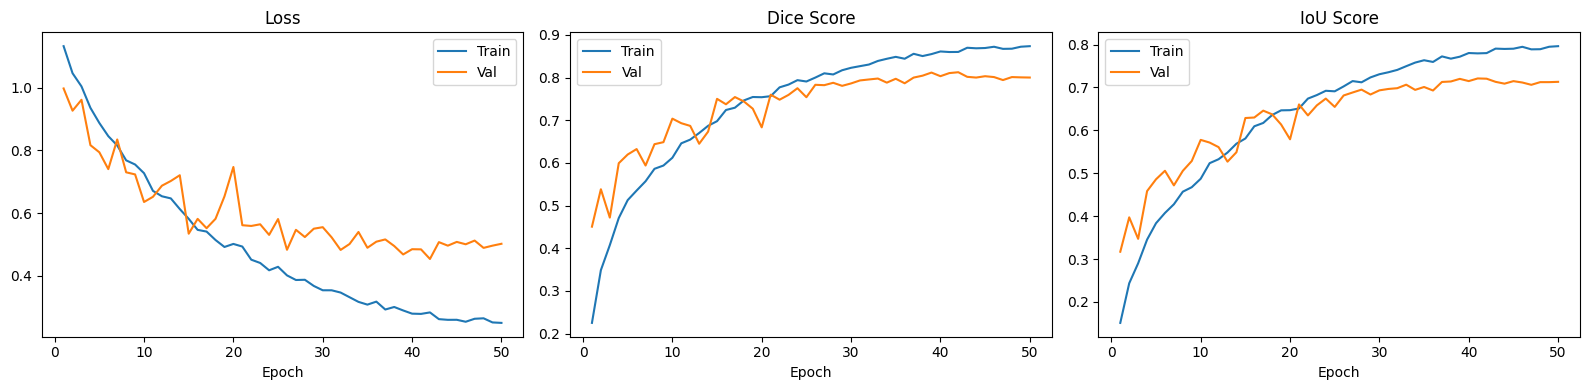

In [42]:
history = train(model, train_loader, val_loader, epochs=50, lr=1e-4, device=device)

## INFERENCE & VISUALIZATION

In [21]:
infer_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])


@torch.no_grad()
def predict(model, image_path, device, threshold=0.5):
    img         = np.array(Image.open(image_path).convert("RGB"))
    original    = img.copy()
    transformed = infer_tf(image=img)["image"].unsqueeze(0).to(device)
    pred        = torch.sigmoid(model(transformed))
    pred_mask   = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)
    return original, pred_mask


def visualize(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    fig.suptitle("TransUNet — Image | Ground Truth | Prediction",
                 fontsize=16, fontweight="bold")

    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = dataset[idx]

        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)
        gt   = mask_tensor.squeeze().numpy()

        axes[row, 0].imshow(img);              axes[row, 0].set_title("Image");        axes[row, 0].axis("off")
        axes[row, 1].imshow(gt,   cmap="gray"); axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred_mask, cmap="gray"); axes[row, 2].set_title("Prediction"); axes[row, 2].axis("off")

    plt.tight_layout()
    plt.savefig("inference_transunet.png", dpi=150, bbox_inches="tight")
    plt.show()


def visualize_overlay(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))
    fig.suptitle("TransUNet — Prediction Overlay",
                 fontsize=16, fontweight="bold")

    for row, idx in enumerate(indices):
        img_tensor, _ = dataset[idx]

        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.float32)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)

        overlay              = img.copy()
        overlay[pred_mask == 1] = [1.0, 0.0, 0.0]
        blended              = (0.6 * img + 0.4 * overlay).clip(0, 1)

        axes[row, 0].imshow(img);     axes[row, 0].set_title("Original");           axes[row, 0].axis("off")
        axes[row, 1].imshow(blended); axes[row, 1].set_title("Prediction Overlay"); axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig("overlay_transunet.png", dpi=150, bbox_inches="tight")
    plt.show()


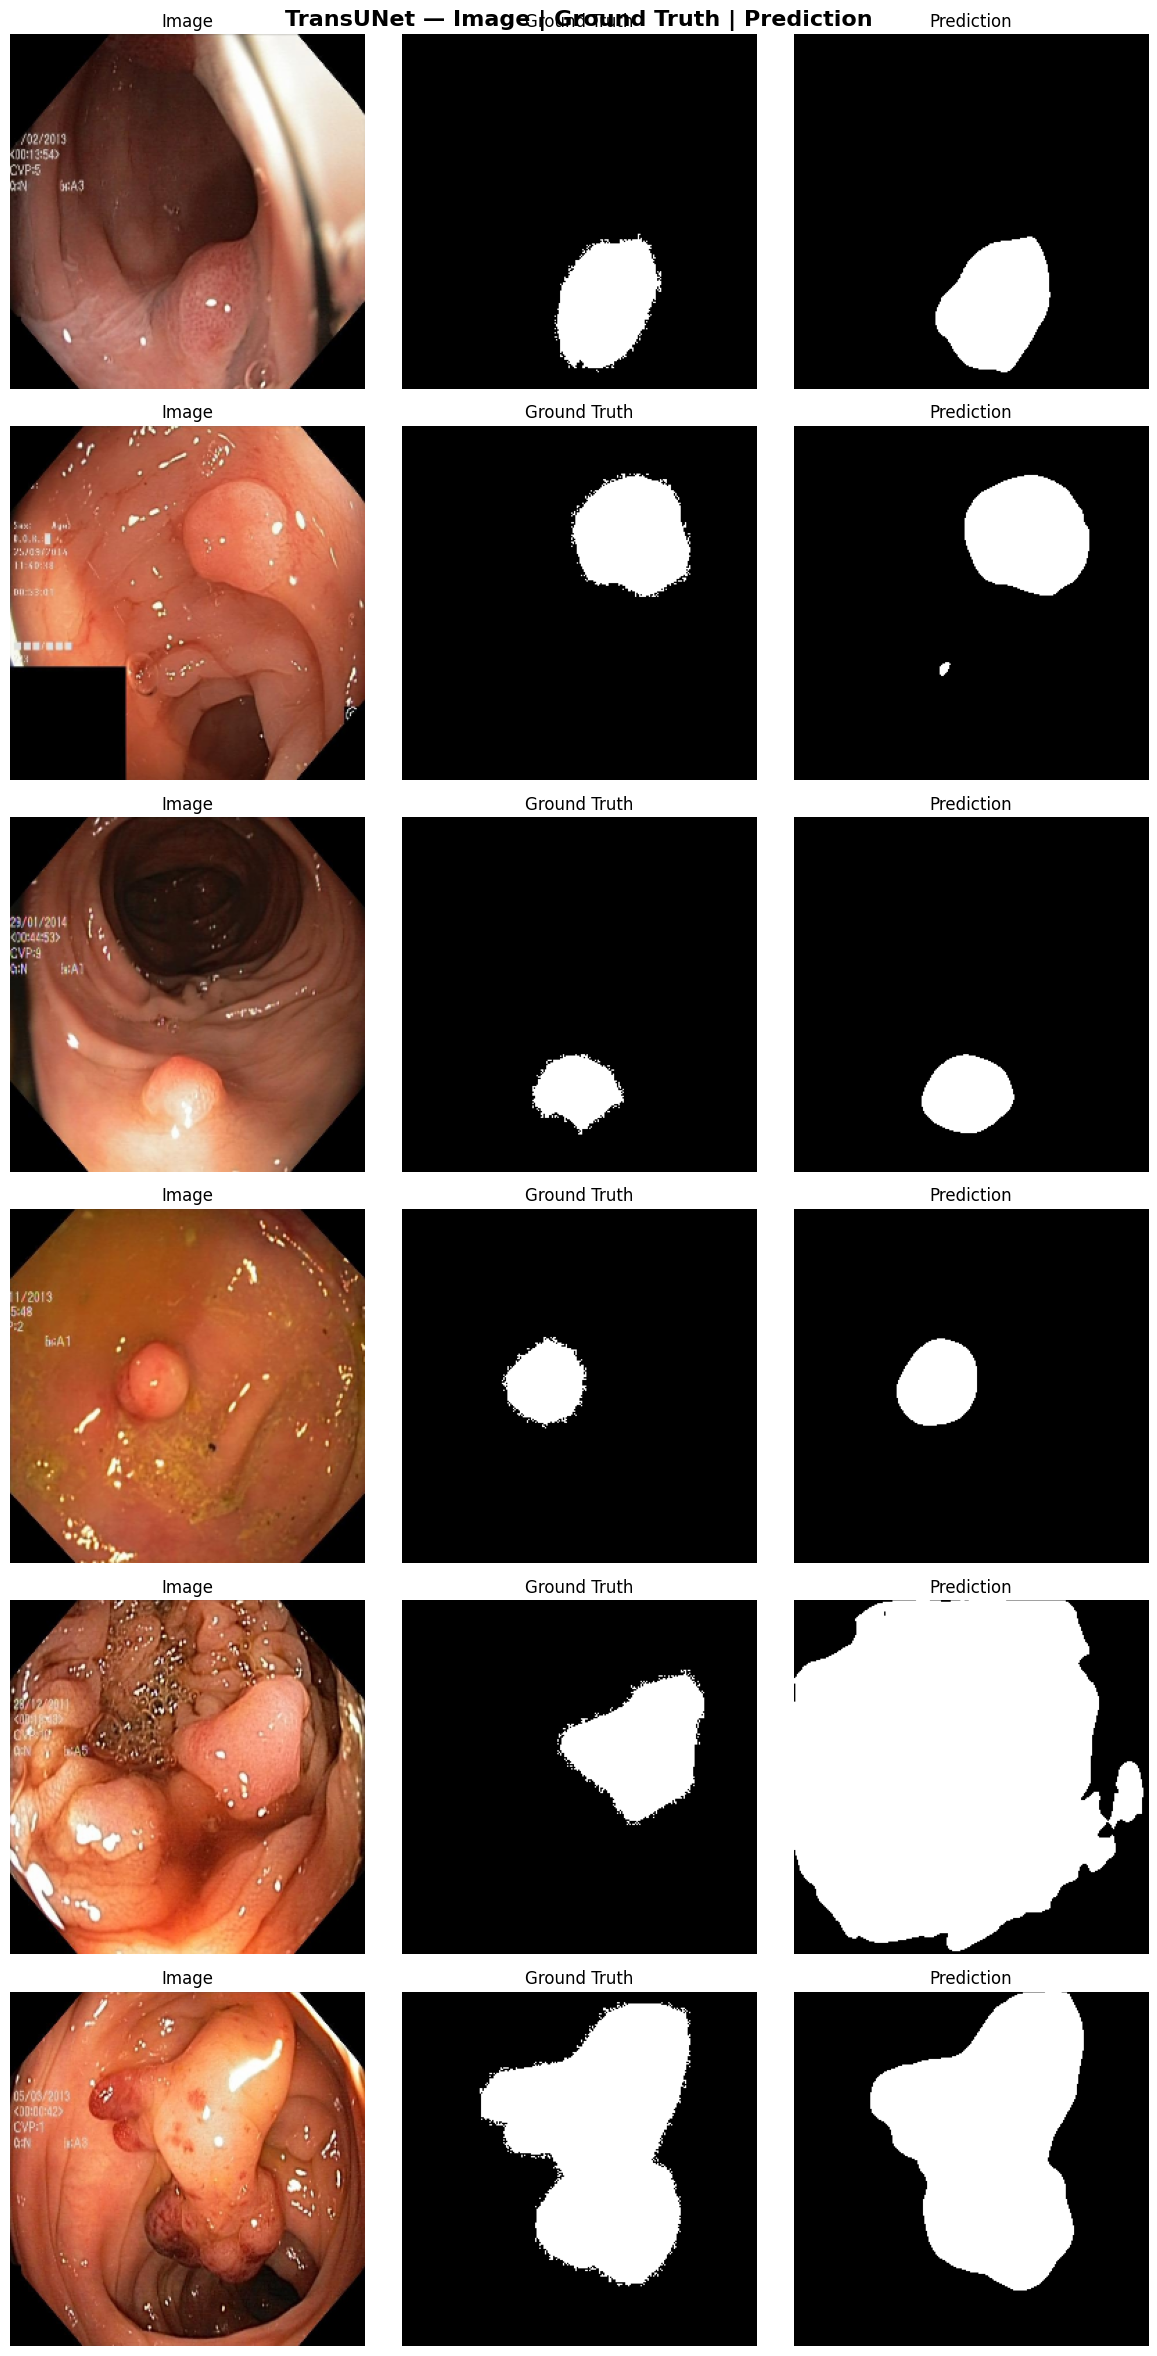

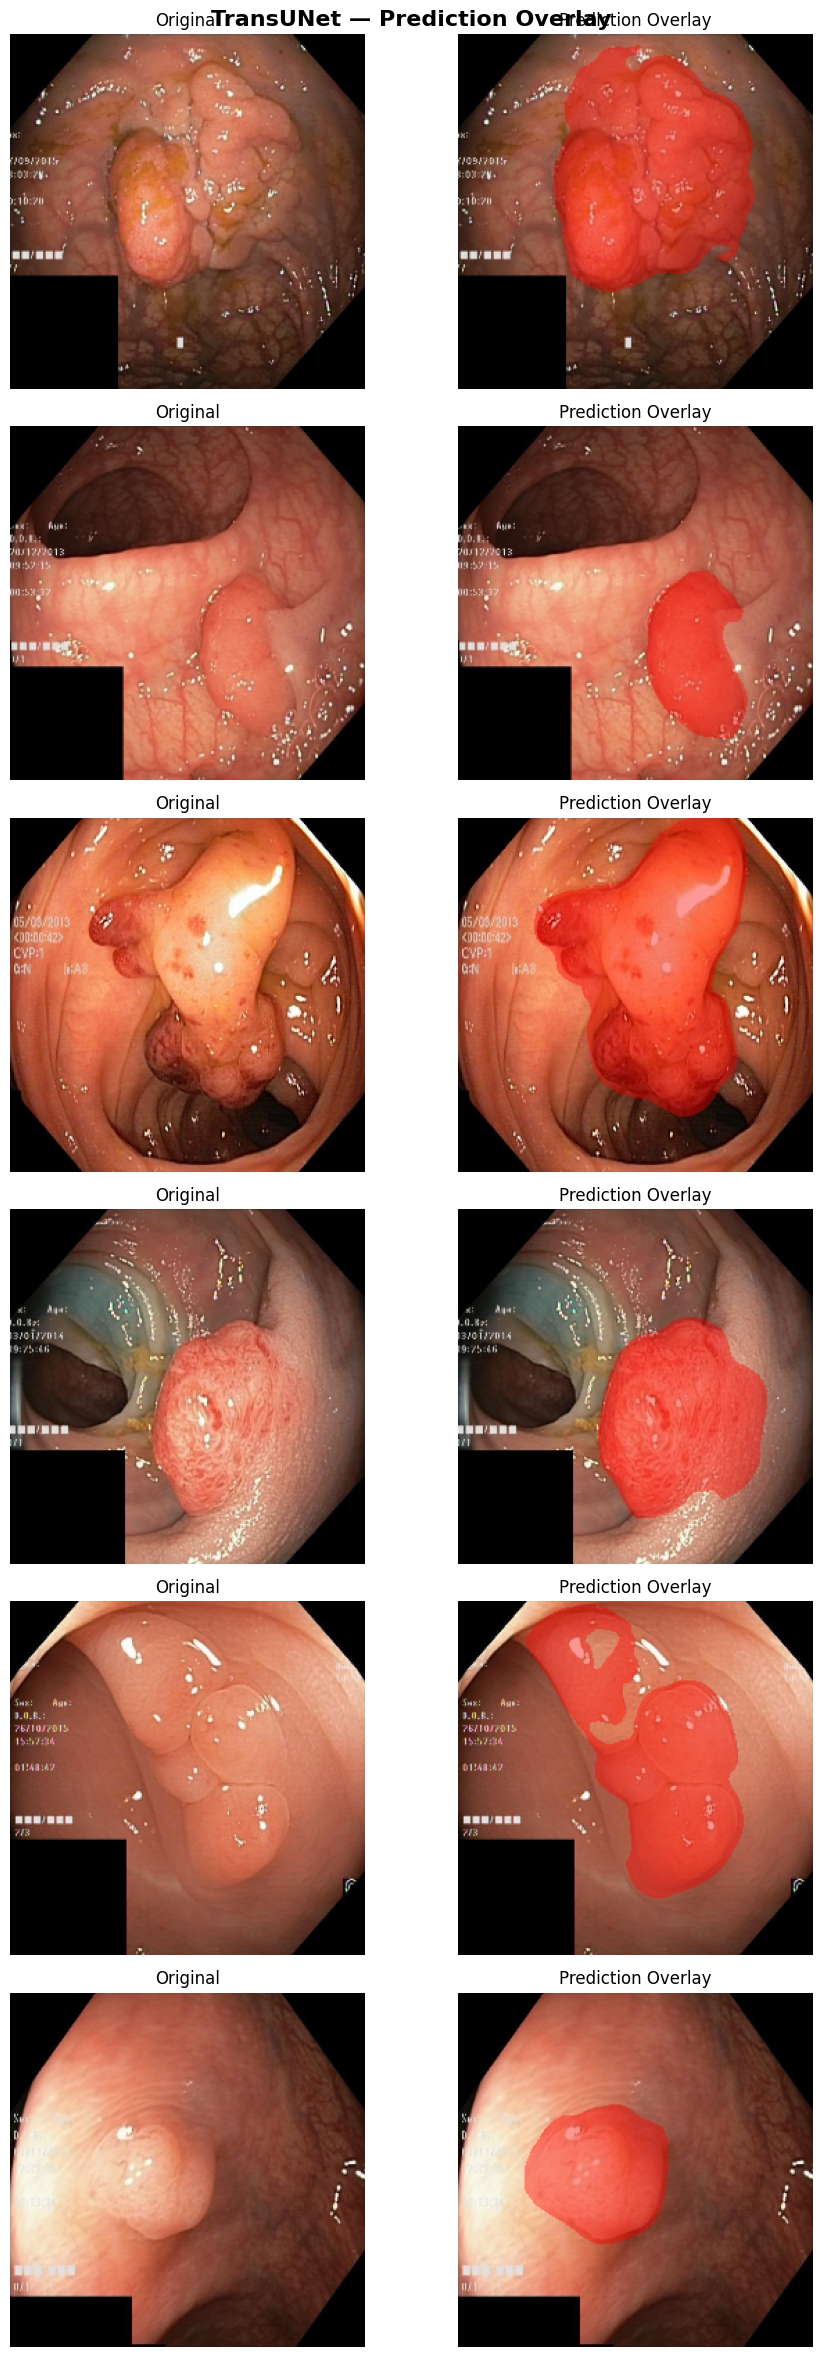

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransUNet(
    num_classes       = 1,
    transformer_depth = 12,   # ← was 6, now matches checkpoint
).to(device)
model.load_state_dict(torch.load("best_transunet.pth", map_location=device))
model.eval()

visualize(model, test_ds, device, num_samples=6)
visualize_overlay(model, test_ds, device, num_samples=6)